In [23]:
# Carregando bibliotecas e base de dados
from ucimlrepo import fetch_ucirepo

import seaborn as sns

from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
# fetch dataset 
diabetes = fetch_ucirepo(id=296) 
  
# data (as pandas dataframes) 
X = diabetes.data.features

# Transformando em variável binária: 1 para readmissão em menos de 30 dias e 0 para os demais casos
y = diabetes.data.targets['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
  
# metadata 
print(diabetes.metadata) 
  
# variable information 
print(diabetes.variables) 

{'uci_id': 296, 'name': 'Diabetes 130-US Hospitals for Years 1999-2008', 'repository_url': 'https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008', 'data_url': 'https://archive.ics.uci.edu/static/public/296/data.csv', 'abstract': 'The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide pro

/home/wagner/anaconda3/envs/ibge-v1/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


In [3]:
# Explorando as primerias linhas do dataset
print(X.head())

# Verificando o tipo do dataset como dataframe do Pandas
type(X)

              race  gender      age weight  admission_type_id  \
0        Caucasian  Female   [0-10)    NaN                  6   
1        Caucasian  Female  [10-20)    NaN                  1   
2  AfricanAmerican  Female  [20-30)    NaN                  1   
3        Caucasian    Male  [30-40)    NaN                  1   
4        Caucasian    Male  [40-50)    NaN                  1   

   discharge_disposition_id  admission_source_id  time_in_hospital payer_code  \
0                        25                    1                 1        NaN   
1                         1                    7                 3        NaN   
2                         1                    7                 2        NaN   
3                         1                    7                 2        NaN   
4                         1                    7                 1        NaN   

          medical_specialty  ...  examide  citoglipton  insulin  \
0  Pediatrics-Endocrinology  ...       No           No 

pandas.core.frame.DataFrame

In [4]:
# Dando uma geral no dataset
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      99493 non-null   object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    3197 non-null    object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                61510 non-null   object
 9   medical_specialty         51817 non-null   object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         101766 non-null  int64 
 14  numb

In [5]:
# Verificando as estatísticas do dataset
X.drop([0, 1, 2, 3, 8, 9, 16, 17, 18, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]).describe()

numeric_cols = X.select_dtypes(include=['int64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Utilizando o ColumnTransformer para aplicar as transformações necessárias em cada tipo de variável
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        # handle_unknown='ignore' é necessário para evitar erros caso haja categorias no conjunto de teste que não estejam presentes no conjunto de treino
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# Criando o pipeline com o pré-processamento e o modelo de classificação com Perceptron
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', Perceptron(class_weight='balanced', random_state=42, max_iter=1000))
])

In [6]:
# Analisando a distribuição da variável alvo
display(y.value_counts())

# Analisando as proporções da variável alvo
display(y.value_counts(normalize=True))

readmitted
0    90409
1    11357
Name: count, dtype: int64

readmitted
0    0.888401
1    0.111599
Name: proportion, dtype: float64

In [7]:
# Verificando o formato dos dados
display(X.shape)
# Verificando o formato da variável alvo
display(y.shape)
display(y.head())
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Treinando com Perceptron
display(model.fit(x_train, y_train))

# Fazendo previsões
y_hat_train = model.predict(x_train)
y_hat_test = model.predict(x_test)

print("Acurácia no conjunto de treino: ", accuracy_score(y_train, y_hat_train))
print("Acurácia no conjunto de teste: ", accuracy_score(y_test, y_hat_test))

print("-"*100)

y_pred = model.predict(x_test)

print("Matriz de confusão (Perceptron):")
print(confusion_matrix(y_test, y_pred))
print("-"*100)
print("Classification Report (Perceptron):")
print(classification_report(y_test, y_pred))

(101766, 47)

(101766,)

0    0
1    0
2    0
3    0
4    0
Name: readmitted, dtype: int64

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Acurácia no conjunto de treino:  0.845752147790443
Acurácia no conjunto de teste:  0.8424500491320013
----------------------------------------------------------------------------------------------------
Matriz de confusão (Perceptron):
[[25269  1854]
 [ 2956   451]]
----------------------------------------------------------------------------------------------------
Classification Report (Perceptron):
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     27123
           1       0.20      0.13      0.16      3407

    accuracy                           0.84     30530
   macro avg       0.55      0.53      0.54     30530
weighted avg       0.82      0.84      0.83     30530



In [8]:
# Treinando o modelo
# Precisei aumentar o número de iterações para garantir a convergência do modelo, além de 
# utilizar class_weight='balanced' para lidar com o desbalanceamento da variável alvo
# A acurácia antes do balanceamento era de 0.88 e Recall classe 1 = 0.02
# Forçando o modelo a dar peso maior para a classe 1
# Ele começou a detectar quase metade dos pacientes de risco.
# Mas aumentou bastante os falsos positivos.
# Ao aplicar balanceamento de classes, houve redução da acurácia global (de 88% para 68%), 
# porém aumento substancial do recall da classe minoritária (de 2% para 49%), 
# demonstrando que a acurácia isoladamente não é métrica adequada para problemas desbalanceados.

# Criando o pipeline com o pré-processamento e o modelo de classificação com Perceptron
model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
# Treinando o modelo de regressão logística
model.fit(x_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
# Fazendo previsões

y_hat_train = model.predict(x_train)
y_hat_test = model.predict(x_test)

In [10]:
print(y_hat_train[:5])
print(y_train.head())

[0 1 0 0 1]
10451    0
19008    0
69902    0
10732    0
90203    0
Name: readmitted, dtype: int64


In [11]:
print("Acurácia no conjunto de treino: ", accuracy_score(y_train, y_hat_train))
print("Acurácia no conjunto de teste: ", accuracy_score(y_test, y_hat_test))

Acurácia no conjunto de treino:  0.6643691391992813
Acurácia no conjunto de teste:  0.6417949557811988


In [12]:
y_pred = model.predict(x_test)

print("-"*100)
print("Matriz de confusão (Regressão Logística):")
print(confusion_matrix(y_test, y_pred))
print("-"*100)
print("Classification Report (Regressão Logística):")
print(classification_report(y_test, y_pred))

----------------------------------------------------------------------------------------------------
Matriz de confusão (Regressão Logística):
[[17765  9358]
 [ 1578  1829]]
----------------------------------------------------------------------------------------------------
Classification Report (Regressão Logística):
              precision    recall  f1-score   support

           0       0.92      0.65      0.76     27123
           1       0.16      0.54      0.25      3407

    accuracy                           0.64     30530
   macro avg       0.54      0.60      0.51     30530
weighted avg       0.83      0.64      0.71     30530



# Análise técnica dos modelos
* Perceptron
    * Modelo linear simples
    * Mesmo com class_weight=balanced, continua enviesado para a classe majoritária
    * Recall extremamente baixo para a classe 1
    * Acurácia alta apenas porque o dataset é desbalanceado
    * Nao é adequado para este tipo de problema
* Regressao Logística
    * Modelo linear probabilístico, mais estável
    * class_weight=balanced funciona muito melhor
    * Recall da classe 1 sobe para 54%
    * Permite ajustar limiar de decisao
    * Muito mais apropriado para problemas de desbalanceamento

Embora o Perceptron apresente acurácia superior, essa métrica é enganosa 
devido ao forte desbalanceamento do dataset. O modelo praticamente ignora a 
classe minoritária, alcançando recall de apenas 13% para pacientes que serão readmitidos.

A Regressão Logística, ao utilizar class_weight='balanced', reduz a acurácia global,
mas aumenta substancialmente o recall da classe 1 para 54%, identificando mais de 
quatro vezes mais pacientes de risco do que o Perceptron.

Em contextos de saúde, onde o custo de um falso negativo é elevado, a Regressão Logística 
se mostra claramente superior, oferecendo um equilíbrio mais adequado entre sensibilidade 
e utilidade prática.

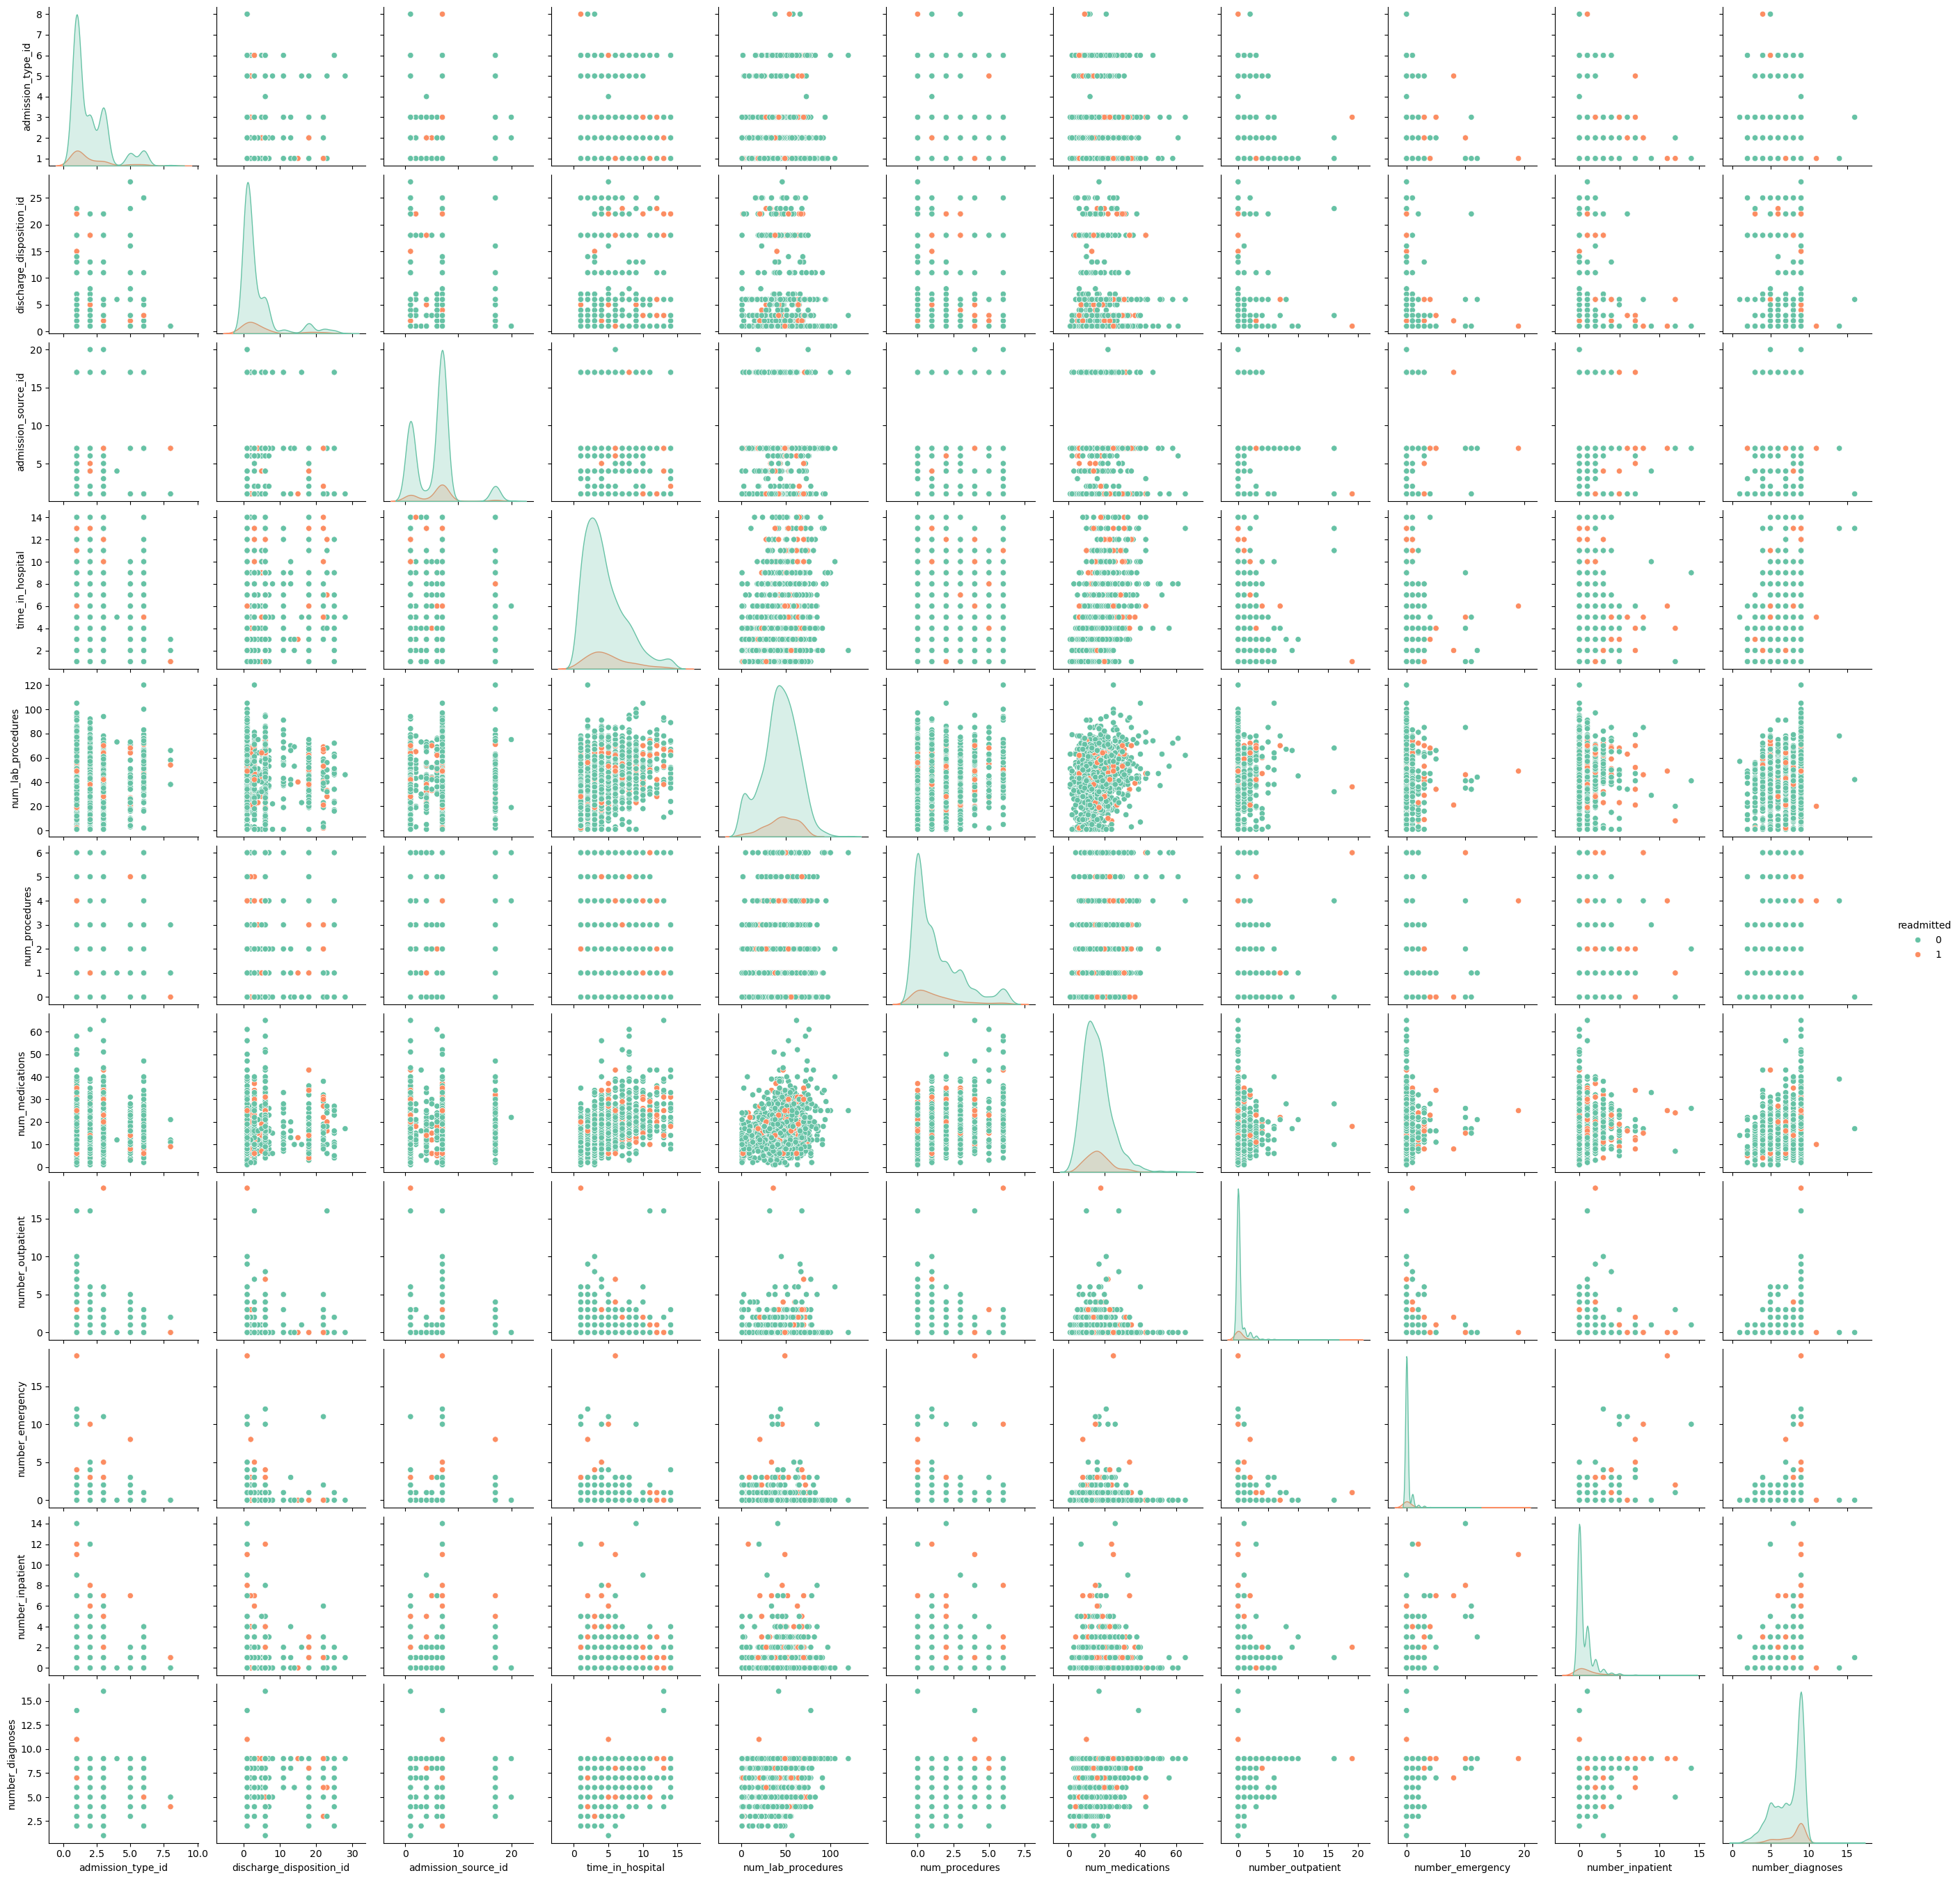

In [22]:
# Pairplot para analisar as relações entre as variáveis numéricas
df_plot = X.copy()
df_plot['readmitted'] = y.astype(str)
sns.pairplot(df_plot.sample(1500),
             vars=numeric_cols,
             diag_kind='kde',
             hue='readmitted',
             palette='Set2')

In [29]:
# Testando com KNN

knn_model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=3))
])

knn_model.fit(x_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
y_hat_train = knn_model.predict(x_train)
y_hat_test = knn_model.predict(x_test)

In [36]:
print("Acurácia no conjunto de treino: ", accuracy_score(y_train, y_hat_train))
print("Acurácia no conjunto de teste: ", accuracy_score(y_test, y_hat_test))

Acurácia no conjunto de treino:  0.9069290808018418
Acurácia no conjunto de teste:  0.8641663937111038


In [38]:
print("-"*100)
print("Matriz de confusão (KNN):")
print(confusion_matrix(y_test, y_hat_test))
print("-"*100)
print("Classification Report (KNN):")
print(classification_report(y_test, y_hat_test))

----------------------------------------------------------------------------------------------------
Matriz de confusão (KNN):
[[26089  1034]
 [ 3113   294]]
----------------------------------------------------------------------------------------------------
Classification Report (KNN):
              precision    recall  f1-score   support

           0       0.89      0.96      0.93     27123
           1       0.22      0.09      0.12      3407

    accuracy                           0.86     30530
   macro avg       0.56      0.52      0.53     30530
weighted avg       0.82      0.86      0.84     30530



# _Comparaçao dos Modelos:_

* KNN
    * Maior acurácia
    * Recall muito baixo (Detecta apenas 9% dos pacientes de risco)
---
    Está favorecendo a classe majoritária
---
* Perceptron
    * Acurária alta
    * Recall ainda baixo
---
    Um pouco melhor que KNN, mas ainda ruim apra classe minoritária
---
* Regressao Logística (balanceada)
    * Acurácia menor
    * Recall muito maior
    * Melhor F1-score da classe 1

    ### Único modelo que tenta capturar os casos críticos
---
> Accuracy pode ser enganosa em datasets desbalanceados
> Modelos não balanceados favorecem a classe majoritária
> Ajuste de class_weight muda completamente o comportamento do modelo
---